# Dataset 1 Analysis

In [1]:
import pandas as pd

df_Lung_Cancer = pd.read_csv("Lung Cancer.csv")
print(df_Lung_Cancer)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1                  2         2       

In [ ]:
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

#Dataset 1
print("DATASET 1: Lung Cancer Dataset")

pd.set_option('display.max_columns', None)

#df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')

df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])

df_Lung_Cancer.columns = df_Lung_Cancer.columns.str.strip()

print("First 5 rows")
print(df_Lung_Cancer.head())

print("\nColumn names:")
print(df_Lung_Cancer.columns.tolist())

print("\nDataset info:")
df_Lung_Cancer.info()

print("\nMissing values:")
print(df_Lung_Cancer.isnull().sum())

for col in df_Lung_Cancer.columns:
    if df_Lung_Cancer[col].dtype == "object":
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].mode()[0])
    else:
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].median())

print("\nMissing values after filling:")
print(df_Lung_Cancer.isnull().sum())

X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)



# Logistic Regression model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X1_scaled, y1, test_size=0.2, random_state=42) #https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/

model.fit(X_train, y_train)

print(classification_report(y_test,model.predict(X_test)))


# Predictions
y_pred1 = model.predict(X_test)

#Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")
print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")
print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")
print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_)
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy" : "accuracy",
    "precision" : "precision",
    "recall" : "recall",
    "f1" : "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1_scaled,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results : Dataset 1 (5-fold CV Baseline - All features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-in-logistic-regression-models/
lr_model_full = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr_model_full.fit(X1_scaled, y1)

feature_importance_df = pd.DataFrame({
    "Feature" : X1.columns,
    "Importance": np.abs(lr_model_full.coef_[0])
}) .sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking (Absolute Coefficient Magnitude)")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Logistic Regressions (Dataset 1)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#INDIVIDUAL FEATURE EXPERIMENTS

individual_feature_results = []

for feature in feature_importance_df["Feature"]:
  X_single = X1[[feature]]

  scaler_single = StandardScaler()
  X_single_scaled = scaler_single.fit_transform(X_single)

  single_model = LogisticRegression(
      random_state=42,
      class_weight="balanced",
      max_iter=1000
  )

  single_cv_results = cross_validate(
      single_model,
      X_single_scaled,
      y1,
      cv=cv,
      scoring=scoring,
      n_jobs=-1
    )

  individual_feature_results.append({
      "Feature_Set": feature,
      "Num_Feature": 1,
      "Accuracy": single_cv_results["test_accuracy"].mean(),
      "Precision": single_cv_results["test_precision"].mean(),
      "Recall": single_cv_results["test_recall"].mean(),
      "F1-score": single_cv_results["test_f1"].mean()
  })

  individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
      by="Recall",
      ascending=False
  ).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS

ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range (1, len(ranked_features) + 1):
      selected_features = ranked_features[:k]
      X_topk = X1[selected_features]

      #Scale the top-k features

      scaler_topk = StandardScaler()
      X_topk_scaled = scaler_topk.fit_transform(X_topk)

      topk_model = LogisticRegression(
          random_state=42,
          class_weight="balanced",
          max_iter=1000
      )

      topk_cv_results = cross_validate(
          topk_model,
          X_topk_scaled,
          y1,
          cv=cv,
          scoring=scoring,
          n_jobs=-1
      )

      topk_results.append({
          "Num_Features": k,
          "Features_Used": ", ".join(selected_features),
          "Accuracy": topk_cv_results["test_accuracy"].mean(),
          "Precision": topk_cv_results["test_precision"].mean(),
          "Recall": topk_cv_results["test_recall"].mean(),
          "F1-score": topk_cv_results["test_f1"].mean()
      })

      topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
          "Num_Features" : X1.shape [1],
          "Features_Used": "All Features (Official Baseline)",
          "Accuracy": baseline_accuracy_cv,
          "Precision": baseline_precision_cv,
          "Recall": baseline_recall_cv,
          "F1-score": baseline_f1_cv

      }])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL

plt.figure(figsize=(10,6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o", color="blue")
plt.axhline(
          y=baseline_recall_cv,
          color="red",
          linestyle="--",
          label=f"All Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Feature vs Recall - Logistic Regression (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




First 5 rows:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2                    

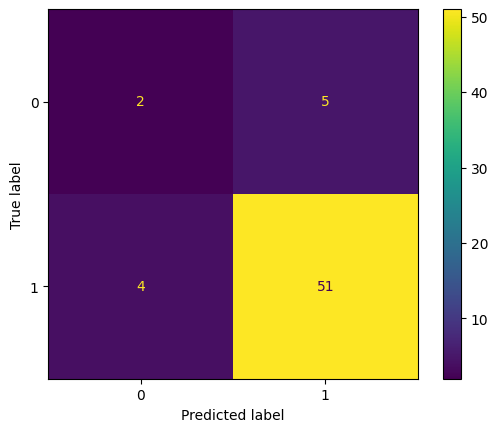


Decision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8902
Mean Precision: 0.9304
Mean Recall   : 0.9444
Mean F1-score : 0.9369

Feature Importance Ranking
                  Feature    Importance
0                 ALLERGY  2.585597e-01
1                     AGE  1.741287e-01
2   SWALLOWING DIFFICULTY  1.232183e-01
3           PEER_PRESSURE  8.911700e-02
4                 ANXIETY  6.521498e-02
5       ALCOHOL CONSUMING  5.238701e-02
6                 SMOKING  4.051639e-02
7                 FATIGUE  3.558585e-02
8                COUGHING  3.503602e-02
9                  GENDER  3.207988e-02
10         YELLOW_FINGERS  2.416295e-02
11               WHEEZING  2.406570e-02
12    SHORTNESS OF BREATH  2.346519e-02
13        CHRONIC DISEASE  2.246235e-02
14             CHEST PAIN  4.221499e-17


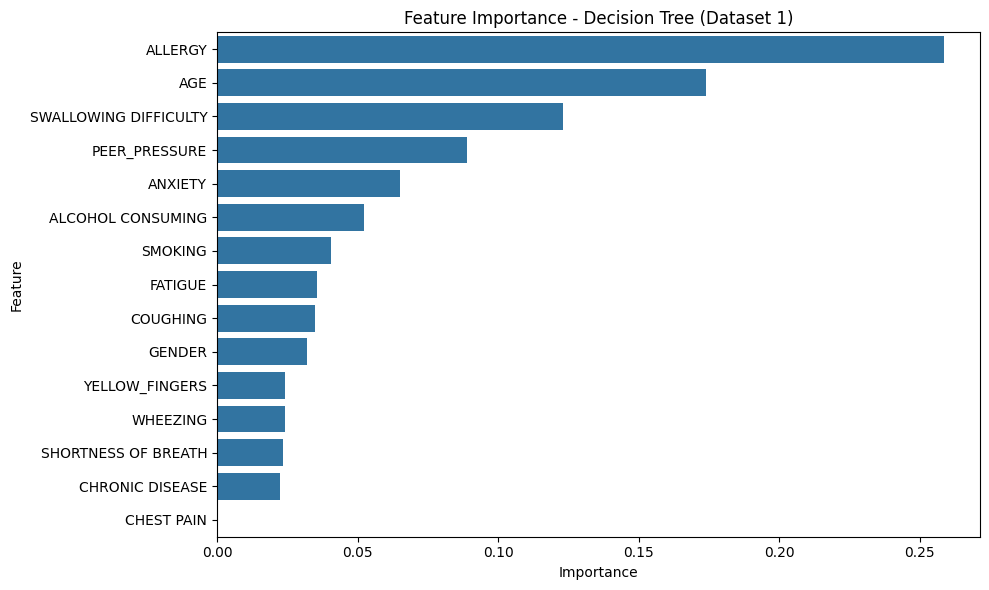


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 FATIGUE             1  0.676097   0.908446  0.700000   
1                     AGE             1  0.647488   0.904488  0.666667   
2     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
3                COUGHING             1  0.640666   0.946563  0.625926   
4                 ALLERGY             1  0.650714   0.970422  0.618519   
5       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
6          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
7                WHEEZING             1  0.624326   0.949043  0.603704   
8              CHEST PAIN             1  0.605182   0.930917  0.592593   
9                 SMOKING             1  0.566526   0.887825  0.574074   
10          PEER_PRESSURE             1  0.563458   0.938938  0.537037   
11                 GENDER             1  0.540561   0.897891  0.537037  

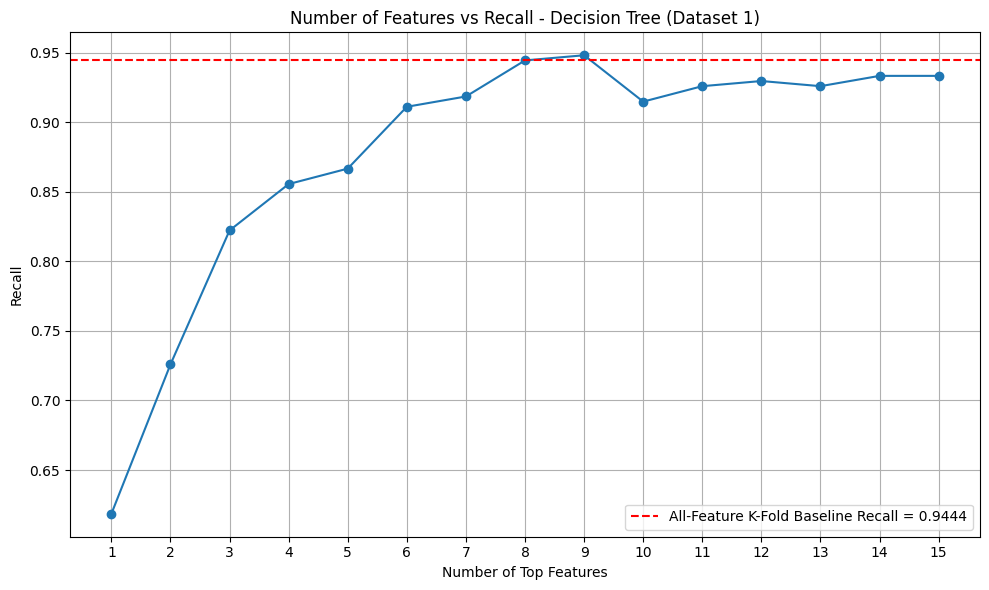

In [2]:
#Dataset 1 - Lung Cancer
import sklearn
from sklearn import tree #https://scikit-learn.org/stable/modules/tree.html
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder #https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)


# Clean column names
df_Lung_Cancer.columns = df_Lung_Cancer.columns.str.strip()

print("First 5 rows:")
print(df_Lung_Cancer.head())

print("\nColumn names:")
print(df_Lung_Cancer.columns.tolist())

print("\nDataset info:")
df_Lung_Cancer.info()

print("\nMissing values:")
print(df_Lung_Cancer.isnull().sum())


# FILL MISSING VALUES
for col in df_Lung_Cancer.columns:
    if df_Lung_Cancer[col].dtype == "object":
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].mode()[0])
    else:
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].median())

print("\nMissing values after filling:")
print(df_Lung_Cancer.isnull().sum())


#ENCODING
df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])
X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report,accuracy_score, precision_score, recall_score, f1_score

print(classification_report(y_test, model.predict(X_test)))


print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

#FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X1, y1)

feature_importance_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 1)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X1[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X1[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X1.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Decision Tree (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

First 5 rows:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2                    

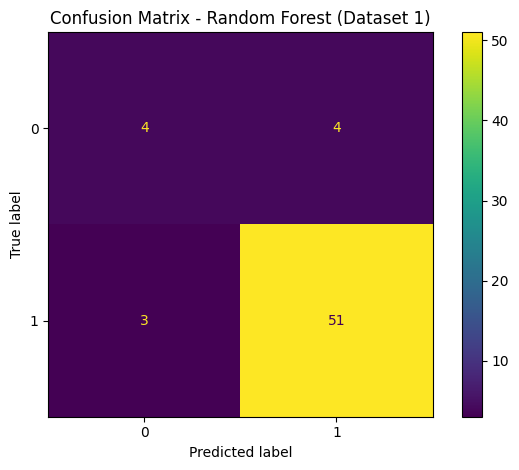


Random Forest Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.9063
Mean Precision: 0.9358
Mean Recall   : 0.9593
Mean F1-score : 0.9469

Feature Importance Ranking
                  Feature  Importance
0                     AGE    0.146451
1                 ALLERGY    0.136953
2       ALCOHOL CONSUMING    0.096429
3   SWALLOWING DIFFICULTY    0.089078
4                 FATIGUE    0.071515
5                COUGHING    0.063552
6           PEER_PRESSURE    0.062383
7                WHEEZING    0.061783
8          YELLOW_FINGERS    0.053601
9                 ANXIETY    0.049492
10             CHEST PAIN    0.040387
11        CHRONIC DISEASE    0.039683
12    SHORTNESS OF BREATH    0.036909
13                 GENDER    0.025925
14                SMOKING    0.025860


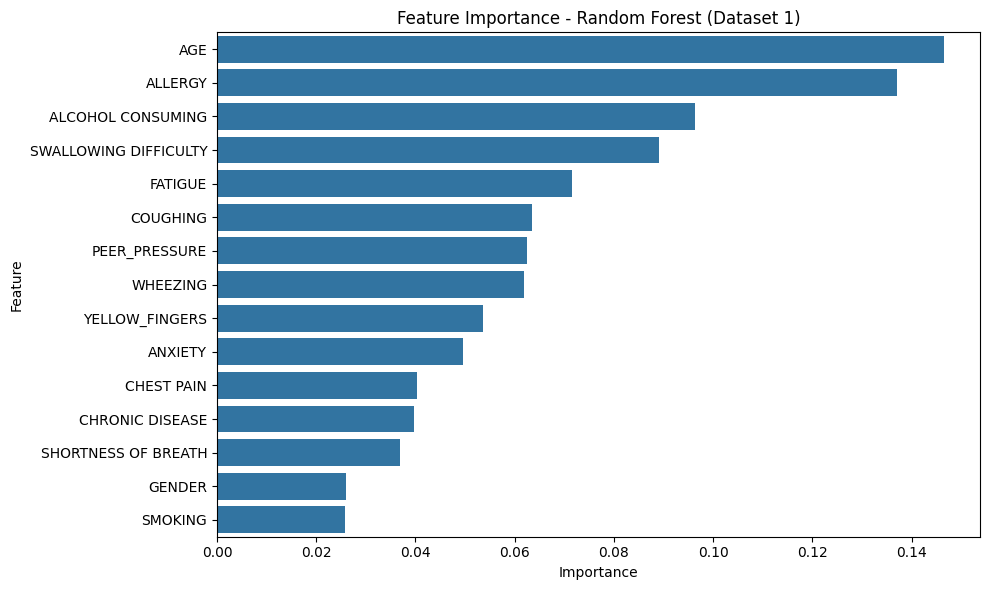


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                     AGE             1  0.682972   0.902633  0.714815   
1                 FATIGUE             1  0.676097   0.908446  0.700000   
2     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
3                  GENDER             1  0.602856   0.874940  0.633333   
4                COUGHING             1  0.640666   0.946563  0.625926   
5                 ALLERGY             1  0.650714   0.970422  0.618519   
6       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
7                WHEEZING             1  0.624326   0.949043  0.603704   
8          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
9              CHEST PAIN             1  0.605182   0.930917  0.592593   
10                SMOKING             1  0.566526   0.887825  0.574074   
11          PEER_PRESSURE             1  0.563458   0.938938  0.537037  

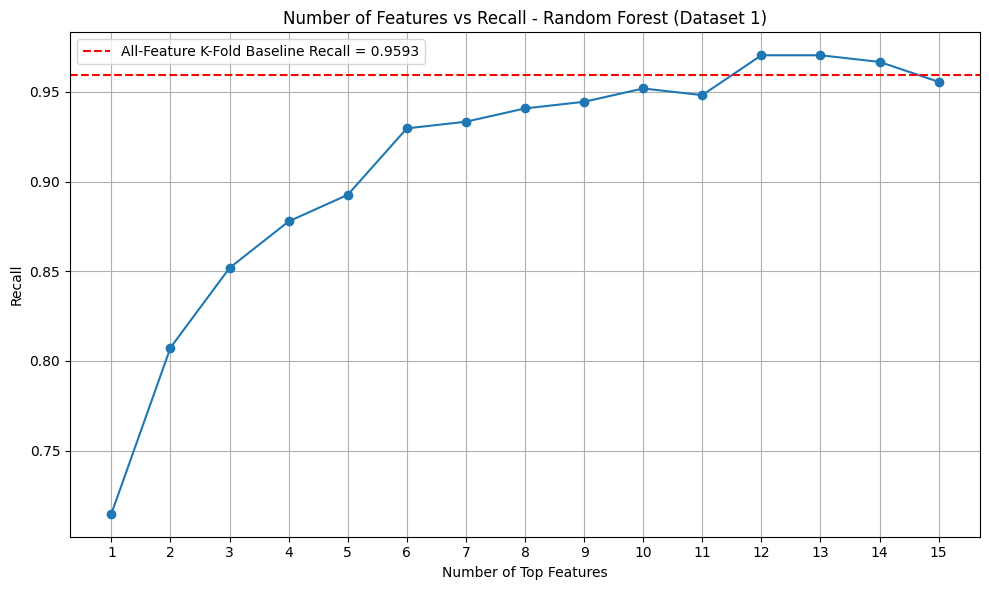

In [ ]:
# Random Forest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# DATASET 1
df1 = df_Lung_Cancer.copy()

# Clean column names
df1.columns = df1.columns.str.strip()

print("First 5 rows:")
print(df1.head())

print("\nColumn names:")
print(df1.columns.tolist())

print("\nDataset info:")
df1.info()

print("\nMissing values:")
print(df1.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df1.columns:
    if df1[col].dtype == "object":
        le = LabelEncoder()
        df1[col] = le.fit_transform(df1[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
target_col = "LUNG_CANCER"
X1 = df1.drop(columns=[target_col])
y1 = df1[target_col]

print("\nClass distribution:")
print(y1.value_counts())

print("\nClass distribution (proportion):")
print(y1.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X1_train, y1_train)
y1_pred = rf_model_split.predict(X1_test)

accuracy_1 = accuracy_score(y1_test, y1_pred)
precision_1 = precision_score(y1_test, y1_pred, zero_division=0)
recall_1 = recall_score(y1_test, y1_pred, zero_division=0)
f1_1 = f1_score(y1_test, y1_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 1 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall   : {recall_1:.4f}")
print(f"F1-score : {f1_1:.4f}")

cm1 = confusion_matrix(y1_test, y1_pred)

print("\nConfusion Matrix:")
print(cm1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 1)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X1, y1)

feature_importance_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 1)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X1[[feature]]

    single_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X1[selected_features]

    topk_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X1.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()